In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from CoupledModel import CoupledModel

In [22]:


AMOC_load = {
    **torch.load('amoc_model.pth', weights_only=False),
    'scaler': 'scalers_AMOC.pkl'
}
SFWF_load = {
    **torch.load('SFWF_model.pth', weights_only=False),
    'scaler': 'scalers_SFWF.pkl'
}
PD_200m_load = {
    **torch.load('PD_200m_model.pth', weights_only=False),
    'scaler': 'scalers_PD_200m.pkl'
}

model = CoupledModel(AMOC_load, SFWF_load, PD_200m_load)

X = pd.read_csv('../data/CESMDataset_Try.csv')
device = 'cpu'
start_idx = 6500
lag = 50

AMOC_features = ['SFWF', 'PD_200m']
SFWF_features = ['AMOC', 'PD_200m']
PD_200m_features = ['SFWF', 'AMOC']

steps = 7000

from scipy.stats import norm

threshold = 13

on = X['AMOC'] > threshold
off = X['AMOC'] < threshold
AMOC_on = X[on]['AMOC']
AMOC_off = X[off]['AMOC']
SFWF_on = X[on]['SFWF']
SFWF_off = X[off]['SFWF']
PD_200m_on = X[on]['PD_200m']
PD_200m_off = X[off]['PD_200m']

data_on  = np.column_stack([AMOC_on, SFWF_on, PD_200m_on])
data_off = np.column_stack([AMOC_off, SFWF_off, PD_200m_off])

cov_on    = np.cov(data_on.T)      
cov_off   = np.cov(data_off.T)

AMOC, SFWF, PD_200m = model.predict(device, X, start_idx, lag, AMOC_features, SFWF_features, PD_200m_features, steps, threshold, cov_on, cov_off)



/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


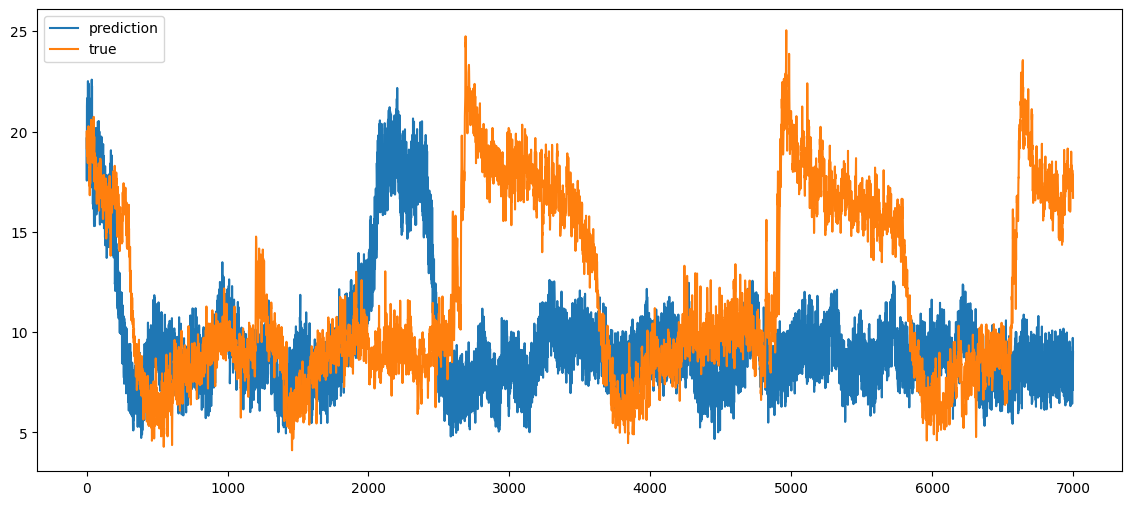

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

x = np.arange(steps+1)

plt.plot(x, AMOC, label = 'prediction')
plt.plot(x, X['AMOC'][start_idx:start_idx+steps+1], label = 'true')
plt.legend()